# Bike Deal Classifier — Training & Evaluation

**Input:** `data/finn_preprocessed.csv` (produced by `bike_deal_classifier.ipynb`)  
**Goal:** Train and compare several classifiers to predict `deal_label ∈ {good_deal, ok_deal, bad_deal}`

**Plan:**
1. Load data & check class balance
2. Baseline (majority-class dummy)
3. Compare: Logistic Regression, Random Forest, Gradient Boosting
4. Best model: full evaluation — confusion matrix, per-class metrics, calibration
5. Feature importance
6. Error analysis — what does the model get wrong?
7. Save model to disk

## 0. Setup

In [22]:
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict,
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 70)

RANDOM_STATE = 42
CLASS_ORDER  = ['good_deal', 'ok_deal', 'bad_deal']

## 1. Load data

In [2]:
df = pd.read_csv('../data/finn_preprocessed.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (722, 18)


,ad_id,source_url,title,price_nok,price_predicted,price_residual_pct,deal_label,condition_score,groupset_tier,brand_tier,carbon_frame,carbon_wheels,electronic_shifting,bike_age,framesize_cm,tilstand,brand,groupset
0,450736924,https://www.finn.no/recommerce/forsale/item/450736924,CANYON Aeroad CF SLX 8.0 DI2,52000.0,35748.107131,45.462247,bad_deal,4.0,4,3,1,1,1,5.0,56.0,Som ny - Ikke synlig brukt,Canyon,Shimano Ultegra Di2
1,413731731,https://www.finn.no/recommerce/forsale/item/413731731,BMC TEAM MACHINE SLR FOUR - SYKKELPAKKE MED WAHOO KICKR CORE OG KO...,45000.0,29785.348563,51.080992,bad_deal,3.0,3,4,1,0,1,5.0,58.0,Pent brukt - I god stand,BMC,SRAM Rival AXS
2,453463150,https://www.finn.no/recommerce/forsale/item/453463150,Trek Madone Two Series landeveissykkel 52 cm unisex rød,7000.0,11682.994710,-40.083855,good_deal,3.0,2,3,0,0,0,5.0,52.0,Pent brukt - I god stand,Trek,Shimano


deal_label
good_deal    222
ok_deal      270
bad_deal     230
Name: count, dtype: int64


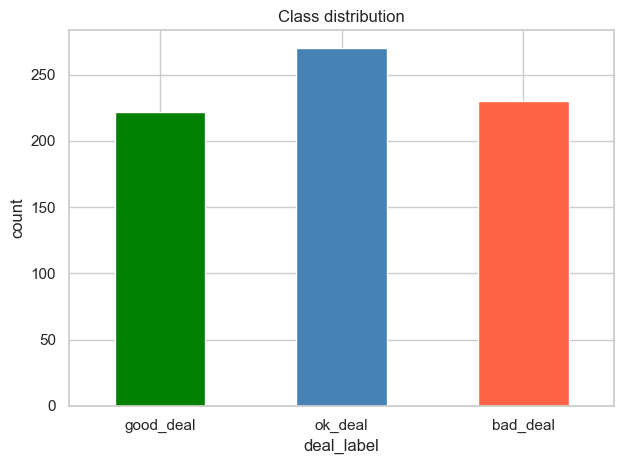

In [3]:
FEATURES = [
    'condition_score',
    'groupset_tier',
    'brand_tier',
    'carbon_frame',
    'carbon_wheels',
    'electronic_shifting',
    'bike_age',
    'framesize_cm',
]

TARGET = 'deal_label'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Class balance
counts = y.value_counts().reindex(CLASS_ORDER)
print(counts)
counts.plot.bar(title='Class distribution', color=['green', 'steelblue', 'tomato'], rot=0)
plt.ylabel('count'); plt.tight_layout()

> **Note on class imbalance:** `ok_deal` will likely dominate.  
> All models below use `class_weight='balanced'` where applicable, and we
> report **weighted F1** as the primary metric (penalises the majority class less).

## 2. Cross-validation helper

In [4]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORE_NAMES = ['f1_weighted', 'f1_macro', 'accuracy']

def evaluate_model(name: str, pipeline) -> dict:
    """Run 5-fold CV and return mean ± std for key metrics."""
    scores = cross_validate(pipeline, X, y, cv=CV,
                             scoring=SCORE_NAMES, return_train_score=False)
    result = {'model': name}
    for s in SCORE_NAMES:
        key = f'test_{s}'
        result[s] = f"{scores[key].mean():.3f} ± {scores[key].std():.3f}"
        result[f'_{s}_mean'] = scores[key].mean()   # for sorting
    return result


results = []

## 3. Model comparison

### 3.1 Baseline — majority-class dummy

In [5]:
dummy = Pipeline([('clf', DummyClassifier(strategy='most_frequent'))])
results.append(evaluate_model('Baseline (majority)', dummy))

### 3.2 Logistic Regression

In [6]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   max_iter=1000,
                   class_weight='balanced',
                   C=1.0,
                   random_state=RANDOM_STATE,
               )),
])
results.append(evaluate_model('Logistic Regression', lr))

### 3.3 Random Forest

In [7]:
rf = Pipeline([
    ('clf', RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
])
results.append(evaluate_model('Random Forest', rf))

### 3.4 Gradient Boosting

In [8]:
gb = Pipeline([
    ('clf', GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                random_state=RANDOM_STATE,
            )),
])
results.append(evaluate_model('Gradient Boosting', gb))

### 3.5 Comparison table

In [9]:
results_df = (
    pd.DataFrame(results)
    .sort_values('_f1_weighted_mean', ascending=False)
    [['model', 'f1_weighted', 'f1_macro', 'accuracy']]
)
results_df

,model,f1_weighted,f1_macro,accuracy
1,Logistic Regression,0.425 ± 0.047,0.421 ± 0.046,0.433 ± 0.041
3,Gradient Boosting,0.403 ± 0.055,0.398 ± 0.056,0.406 ± 0.052
2,Random Forest,0.387 ± 0.045,0.382 ± 0.044,0.389 ± 0.041
0,Baseline (majority),0.204 ± 0.001,0.181 ± 0.000,0.374 ± 0.001


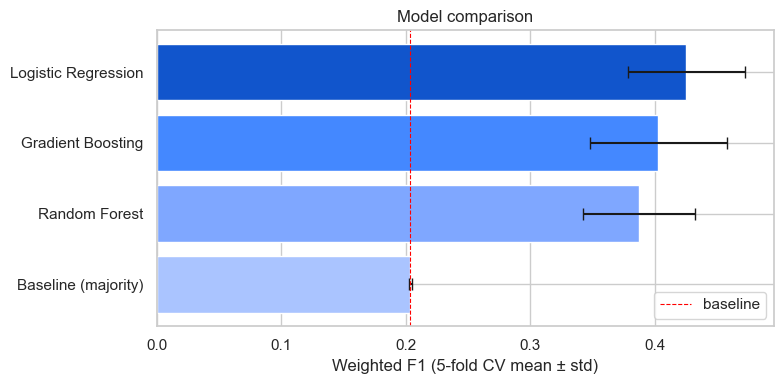

In [10]:
# Visual comparison of weighted-F1 (mean ± std)
plot_df = pd.DataFrame(results).sort_values('_f1_weighted_mean')
means = plot_df['_f1_weighted_mean'].values
stds  = [float(r.split('±')[1]) for r in plot_df['f1_weighted']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(plot_df['model'], means, xerr=stds, capsize=4,
               color=['#aac4ff', '#7fa7ff', '#4488ff', '#1155cc'][:len(plot_df)])
ax.set_xlabel('Weighted F1 (5-fold CV mean ± std)')
ax.set_title('Model comparison')
ax.axvline(means[0], color='red', linestyle='--', linewidth=0.8, label='baseline')
ax.legend()
plt.tight_layout()

## 4. Best model — full evaluation

We use **out-of-fold predictions** from 5-fold CV so we evaluate on every sample exactly once without fitting a train/test split.

In [11]:
# Change this to whichever model won above
BEST_MODEL_NAME = 'Gradient Boosting'
BEST_PIPELINE   = gb   # swap to `rf` or `lr` if needed

y_pred_oof = cross_val_predict(BEST_PIPELINE, X, y, cv=CV, method='predict')
y_prob_oof = cross_val_predict(BEST_PIPELINE, X, y, cv=CV, method='predict_proba')

print(f'Model: {BEST_MODEL_NAME}')
print(classification_report(y, y_pred_oof, target_names=CLASS_ORDER))

Model: Gradient Boosting
              precision    recall  f1-score   support

   good_deal       0.37      0.30      0.33       230
     ok_deal       0.37      0.43      0.40       222
    bad_deal       0.47      0.47      0.47       270

    accuracy                           0.41       722
   macro avg       0.40      0.40      0.40       722
weighted avg       0.41      0.41      0.40       722



### 4.1 Confusion matrix

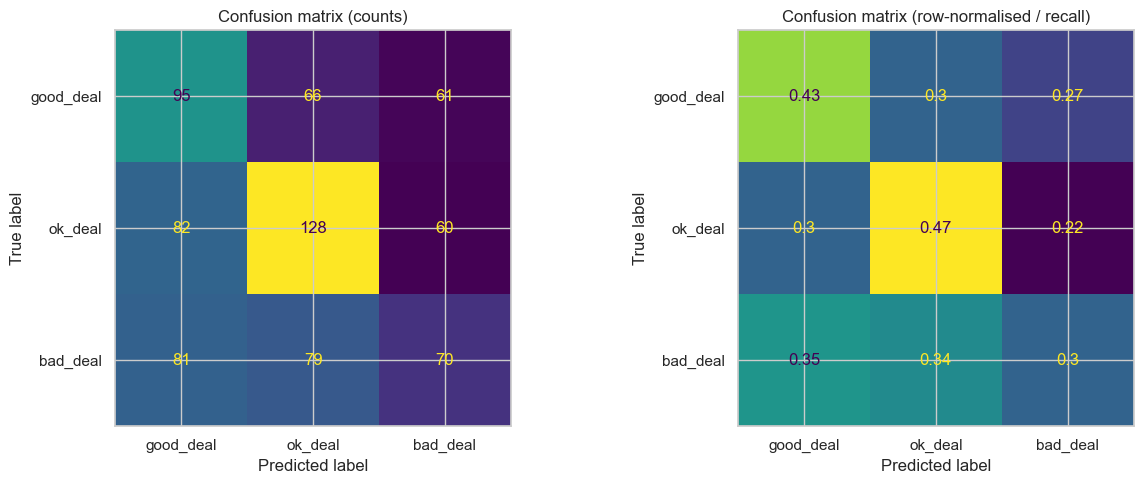

In [12]:
cm = confusion_matrix(y, y_pred_oof, labels=CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix (counts)')

# Normalised (recall per row)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=CLASS_ORDER).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion matrix (row-normalised / recall)')

plt.tight_layout()

### 4.2 ROC-AUC (one-vs-rest)

Macro OVR AUC: 0.571


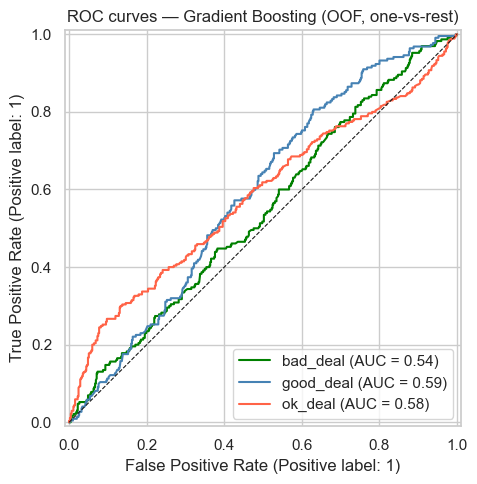

In [13]:
# Get the class order that predict_proba uses
BEST_PIPELINE.fit(X, y)   # fit once on all data just to read .classes_
clf_classes = BEST_PIPELINE.named_steps['clf'].classes_.tolist()

y_bin = label_binarize(y, classes=clf_classes)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['green', 'steelblue', 'tomato']

for i, (cls, color) in enumerate(zip(clf_classes, colors)):
    RocCurveDisplay.from_predictions(
        y_bin[:, i],
        y_prob_oof[:, i],
        name=cls,
        color=color,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title(f'ROC curves — {BEST_MODEL_NAME} (OOF, one-vs-rest)')
plt.tight_layout()

# Macro AUC
auc = roc_auc_score(y_bin, y_prob_oof, multi_class='ovr', average='macro')
print(f'Macro OVR AUC: {auc:.3f}')

### 4.3 Confidence distribution

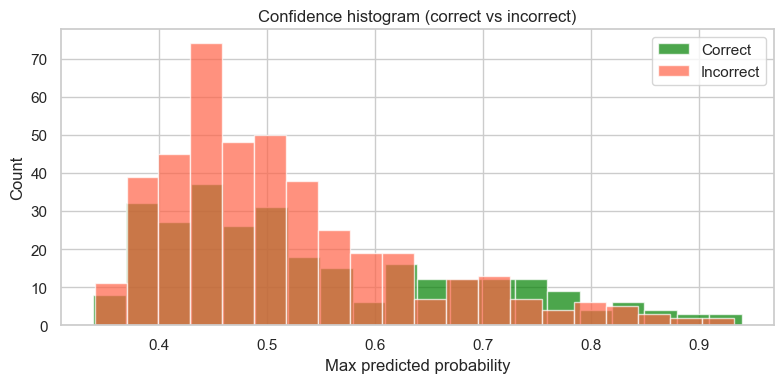

In [14]:
max_prob = y_prob_oof.max(axis=1)
correct  = y_pred_oof == y.values

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(max_prob[correct],  bins=20, alpha=0.7, label='Correct',   color='green')
ax.hist(max_prob[~correct], bins=20, alpha=0.7, label='Incorrect', color='tomato')
ax.set_xlabel('Max predicted probability')
ax.set_ylabel('Count')
ax.set_title('Confidence histogram (correct vs incorrect)')
ax.legend()
plt.tight_layout()

## 5. Feature importance

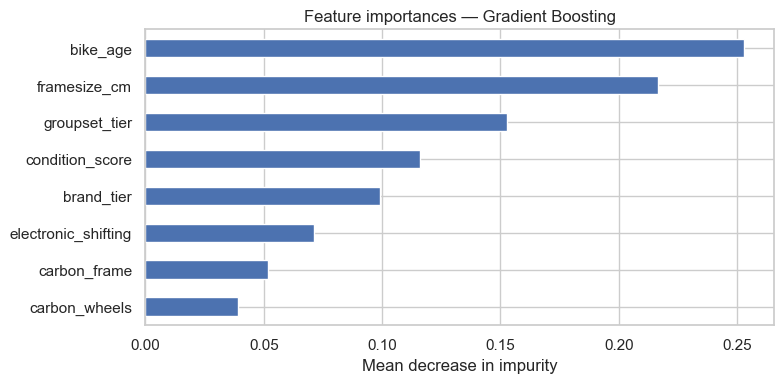

In [15]:
# Tree-based importance (only for RF / GB)
clf_step = BEST_PIPELINE.named_steps['clf']

if hasattr(clf_step, 'feature_importances_'):
    importances = pd.Series(clf_step.feature_importances_, index=FEATURES)
    importances.sort_values().plot.barh(
        title=f'Feature importances — {BEST_MODEL_NAME}',
        figsize=(8, 4),
    )
    plt.xlabel('Mean decrease in impurity')
    plt.tight_layout()
else:
    # Logistic Regression: show coefficients per class
    coef_df = pd.DataFrame(
        clf_step.coef_,
        index=clf_step.classes_,
        columns=FEATURES,
    ).T
    coef_df.plot.barh(figsize=(9, 5), title='LR coefficients per class')
    plt.axvline(0, color='k', linewidth=0.8)
    plt.tight_layout()

## 6. Error analysis

Which listings does the model confidently get wrong?

In [16]:
DISPLAY_COLS = ['title', 'price_nok', 'price_predicted', 'price_residual_pct',
                'deal_label', 'tilstand', 'brand', 'groupset',
                'carbon_frame', 'electronic_shifting']

errors = df.copy()
errors['y_pred']    = y_pred_oof
errors['max_prob']  = max_prob
errors['correct']   = correct

worst_errors = (
    errors[~errors['correct']]
    .sort_values('max_prob', ascending=False)
    .head(10)
)

worst_errors[['title', 'price_nok', 'price_residual_pct', 'deal_label',
              'y_pred', 'max_prob', 'tilstand', 'brand', 'groupset_tier',
              'carbon_frame', 'electronic_shifting']].round(1)

,title,price_nok,price_residual_pct,deal_label,y_pred,max_prob,tilstand,brand,groupset_tier,carbon_frame,electronic_shifting
404,Trek Emonde SLR Disc . Str. 60,45000.0,38.8,bad_deal,ok_deal,0.9,Pent brukt - I god stand,Trek,3,1,1
707,Canyon Aeroad CF SLX 7 | Size M,54000.0,30.3,bad_deal,ok_deal,0.9,Som ny - Ikke synlig brukt,Canyon,3,1,1
218,Gavia Verona Landeveissykkel i XL størrelse til salgs,13500.0,18.4,ok_deal,bad_deal,0.9,Som ny - Ikke synlig brukt,Gavia,4,1,0
646,Bianchi DI2 ( Team Rynkeby),15000.0,-29.9,good_deal,ok_deal,0.9,Pent brukt - I god stand,Bianchi,4,1,1
94,Merida scultura endurance 6000 Carbon Di2 XS NY!,29000.0,55.9,bad_deal,ok_deal,0.9,Helt ny - Uåpnet/med lapp,Merida,2,1,1
493,Factor Ostro Vam V2 2025 wattkrank,22025.0,-52.9,good_deal,ok_deal,0.9,Pent brukt - I god stand,Factor,4,1,1
666,Eddy Merckx Corsa Extra,7000.0,-14.6,ok_deal,good_deal,0.9,Godt brukt - Synlig brukt,Eddy Merckx,1,0,0
401,Orbea Orca M11iLTD-D (toppmodell),35000.0,4.2,ok_deal,bad_deal,0.8,Pent brukt - I god stand,Orbea,5,1,1
663,Fara f/Road 2024 56cm,40000.0,23.0,bad_deal,ok_deal,0.8,Pent brukt - I god stand,Fara,3,1,1
455,Specialized Aethos Expert - str. 58 – SRAM Rival eTap – topp oppgr...,55000.0,50.8,bad_deal,ok_deal,0.8,Som ny - Ikke synlig brukt,Specialized,3,1,1


In [17]:
# Confusion pattern: what does the model confuse most?
confusion_pairs = (
    errors[~errors['correct']]
    .groupby(['deal_label', 'y_pred'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
)
confusion_pairs.columns = ['true_label', 'predicted_as', 'count']
print(confusion_pairs.to_string(index=False))

true_label predicted_as  count
   ok_deal    good_deal     82
  bad_deal    good_deal     81
  bad_deal      ok_deal     79
 good_deal      ok_deal     66
 good_deal     bad_deal     61
   ok_deal     bad_deal     60


## 7. Hyperparameter sensitivity (optional)

Quick grid search over a few key parameters for Gradient Boosting.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__n_estimators':  [100, 200, 300],
    'clf__learning_rate': [0.03, 0.05, 0.1],
    'clf__max_depth':     [2, 3, 4],
}

gs = GridSearchCV(
    BEST_PIPELINE,
    param_grid,
    cv=CV,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
)
gs.fit(X, y)

print('Best params: ', gs.best_params_)
print(f'Best CV F1:  {gs.best_score_:.3f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params:  {'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 200}
Best CV F1:  0.410


In [19]:
# Re-evaluate the tuned model
tuned_pred = cross_val_predict(gs.best_estimator_, X, y, cv=CV)
print(classification_report(y, tuned_pred, target_names=CLASS_ORDER))

              precision    recall  f1-score   support

   good_deal       0.35      0.25      0.29       230
     ok_deal       0.39      0.47      0.43       222
    bad_deal       0.48      0.51      0.50       270

    accuracy                           0.42       722
   macro avg       0.41      0.41      0.41       722
weighted avg       0.41      0.42      0.41       722



## 8. Train final model on all data & save

In [20]:
final_model = gs.best_estimator_   # or swap back to BEST_PIPELINE if you skipped grid search
final_model.fit(X, y)

MODEL_PATH = '../models/bike_deal_classifier.joblib'

import os; os.makedirs('../models', exist_ok=True)
joblib.dump({'model': final_model, 'features': FEATURES, 'classes': CLASS_ORDER}, MODEL_PATH)
print(f'Model saved → {MODEL_PATH}')

Model saved → ../models/bike_deal_classifier.joblib


## 9. Quick-score a new listing

Shows how to use the saved model to score a fresh listing.

In [21]:
artifact = joblib.load(MODEL_PATH)
model    = artifact['model']
features = artifact['features']

# Example: Canyon Aeroad with Dura-Ace Di2, carbon everything, perfect condition
new_listing = pd.DataFrame([{
    'condition_score':     4,    # "Som ny"
    'groupset_tier':       5,    # Dura-Ace
    'brand_tier':          3,    # Canyon
    'carbon_frame':        1,
    'carbon_wheels':       1,
    'electronic_shifting': 1,
    'bike_age':            2,    # 2 years old
    'framesize_cm':        54,
}])

pred  = model.predict(new_listing[features])[0]
probs = dict(zip(model.classes_, model.predict_proba(new_listing[features])[0].round(3)))

print(f'Predicted label: {pred}')
print(f'Probabilities:   {probs}')

Predicted label: ok_deal
Probabilities:   {'bad_deal': 0.308, 'good_deal': 0.116, 'ok_deal': 0.576}
